# Understand Dataset

In [137]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# import re
# import string

# from collections import Counter

In [138]:
df=pd.read_csv("/content/Combined Data.csv")
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [139]:
df.shape

(53044, 3)

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53044 entries, 0 to 53043
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53044 non-null  object
 1   statement   52681 non-null  object
 2   status      53042 non-null  object
dtypes: object(3)
memory usage: 1.2+ MB


In [141]:
df.drop(columns='Unnamed: 0',inplace=True)

In [142]:
df.isnull().sum()

,0
statement,363
status,2


In [143]:
df.dropna(inplace=True)

In [144]:
df.isnull().sum()

,0
statement,0
status,0


In [145]:
df.duplicated().sum()

np.int64(1592)

In [146]:
df.drop_duplicates(inplace=True)

In [147]:
df.duplicated().sum()

np.int64(0)

In [148]:
df.reset_index(drop=True, inplace=True)
df.shape

(51088, 2)

# EDA

In [149]:
df['status'].value_counts()

,count
status,
Normal,16039
Depression,15093
Suicidal,10641
Anxiety,3623
Bipolar,2501
Stress,2296
Personality disorder,895


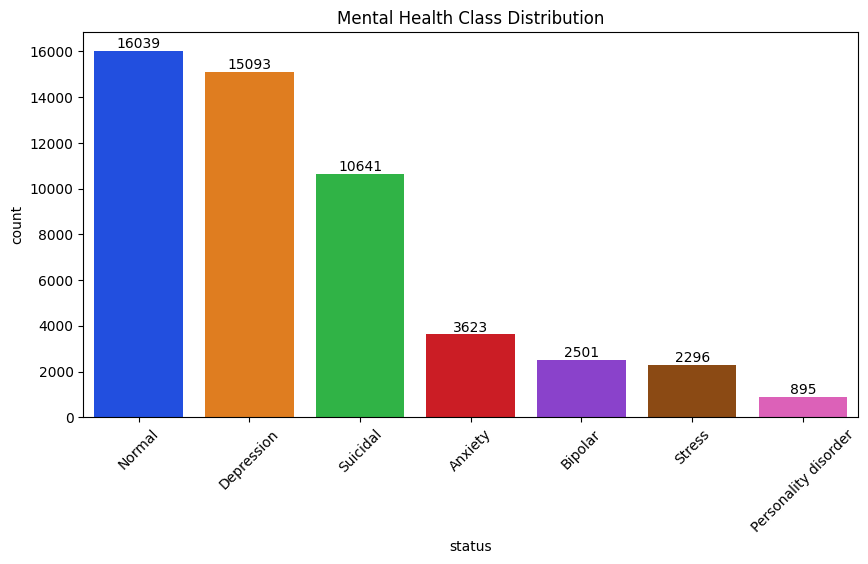

In [150]:
plt.figure(figsize=(10,5))

ax=sns.countplot(
    data=df,
    x='status',
    order=df['status'].value_counts().index,
    palette="bright"
)
for i in ax.containers:
  ax.bar_label(i)

plt.title("Mental Health Class Distribution")
plt.xticks(rotation=45)
plt.show()

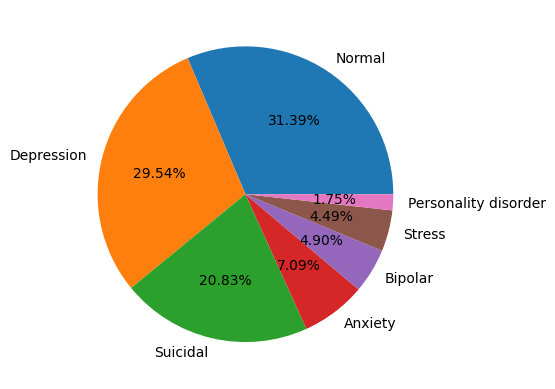

In [151]:
counts = df['status'].value_counts()
labels = counts.index

plt.pie(counts, labels=labels, autopct='%1.2f%%')
plt.show()

In [152]:
df['sentence_length'] = df['statement'].apply(len)
df.head()

,statement,status,sentence_length
0,oh my gosh,Anxiety,10
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,78
3,I've shifted my focus to something else but I'...,Anxiety,61
4,"I'm restless and restless, it's been a month n...",Anxiety,72


In [153]:
# df['sentence_length'].describe()

In [154]:
# plt.figure(figsize=(10,5))

# sns.histplot(df['char_length'], bins=50)

# plt.title("Character Length Distribution")

# plt.show()

In [155]:
# plt.figure(figsize=(25, 6))  # Slightly wider figure so the numbers don't overlap

# # Define the sequence from 5 up to 100 (inclusive of 100) with a step of 5
# custom_bins = list(range(5, 1000, 5))

# # Pass the sequence to the bins parameter
# sns.histplot(df["word_count"], bins=custom_bins, kde=True)

# # Zoom in on the 0 to 105 range so the last bin fits nicely
# plt.xlim(0, 105)

# # Set the x-axis tick marks exactly at your bin intervals
# plt.xticks(list(range(5, 350, 5)))

# plt.title("Distribution of Statement Length")
# plt.xlabel("Number of Words")
# plt.show()

In [156]:
df['word_count'] = df['statement'].apply(lambda x: len(str(x).split()))
df.head()

,statement,status,sentence_length,word_count
0,oh my gosh,Anxiety,10,3
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,10
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,78,14
3,I've shifted my focus to something else but I'...,Anxiety,61,11
4,"I'm restless and restless, it's been a month n...",Anxiety,72,14


In [157]:
# df['word_count'].describe()

In [158]:
# plt.figure(figsize=(10,5))

# sns.histplot(df['word_count'], bins=50)

# plt.title("Word Count Distribution")

# plt.show()

In [159]:
# df['avg_word_length'] = (df['sentence_length'] / df['word_count'])
# df.head()

In [160]:
df['vocabulary_size'] = df['statement'].apply(lambda x: len(set(str(x).split())))
df.head()

,statement,status,sentence_length,word_count,vocabulary_size
0,oh my gosh,Anxiety,10,3,3
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,10,10
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,78,14,13
3,I've shifted my focus to something else but I'...,Anxiety,61,11,11
4,"I'm restless and restless, it's been a month n...",Anxiety,72,14,14


In [161]:
from collections import Counter

all_words = " ".join(df['statement']).split()

word_freq = Counter(all_words)

word_freq.most_common(20)

[('I', 309231),
 ('to', 187663),
 ('and', 162747),
 ('the', 115333),
 ('a', 111401),
 ('my', 105434),
 ('of', 80997),
 ('i', 77820),
 ('not', 71591),
 ('is', 66935),
 ('have', 66845),
 ('it', 63620),
 ('that', 61135),
 ('am', 59957),
 ('in', 56760),
 ('me', 54410),
 ('do', 50218),
 ('for', 50178),
 ('but', 47067),
 ('just', 45084)]

In [162]:
# from wordcloud import WordCloud

# text = " ".join(df['statement'])

# wordcloud = WordCloud(
#     width=1200,
#     height=600,
#     background_color='white'
# ).generate(text)

# plt.figure(figsize=(15,8))

# plt.imshow(wordcloud)

# plt.axis("off")

# plt.show()

# Preprocessing

In [163]:
df['statement'].sample(5,random_state=10).values

array(['Yup like I said no idea, guess I got no one else but strangers online and texts on a screen. I cannot seem to figure out a reason to keep going. Life just seems like pain, sadness and hardship until you die. I have everything I was taught I should be grateful for, a loving and supportive girlfriend, good money, great friends, and a good family but I cannot stop the almost daily thoughts of throwing it all away forever. it is so fucking frustrating and makes no sense why I feel this way. A good friend of mine recently committed suicide and it really messed me up. I used to think about all the people in my life that would miss me if I gave into my thoughts like I was doing them a favor by not going through with it like I am special or something. But I am not I am just 1 of 7 billion and life will go on with or without me. I do not know what I am expecting from doing this but I have heard talking about shit helps Not really sure why I am doing this',
       "How can you reduce the

In [164]:
pip install contractions emoji

In [165]:
import re
import html
import unicodedata

import contractions
import emoji
import string

In [166]:
def normalize_unicode(text):
    return unicodedata.normalize("NFKC", text)

In [167]:
def to_lower(text):
    return text.lower()

In [168]:
def expand_contractions(text):
    return contractions.fix(text)

In [169]:
def remove_urls(text):
    return re.sub(r'http\S+|www\S+', '', text)

In [170]:
def remove_html(text):
    text = html.unescape(text)
    return re.sub(r'<.*?>', '', text)

In [171]:
def remove_emails(text):
    return re.sub(r'\S+@\S+', '', text)

In [172]:
def remove_mentions(text):
    return re.sub(r'@\w+', '', text)

In [173]:
def convert_emojis(text):
    return emoji.demojize(text, delimiters=(" ", " "))

In [174]:
def normalize_repeated_chars(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

In [175]:
def remove_extra_spaces(text):
    return re.sub(r'\s+', ' ', text).strip()

In [176]:
# def remove_punctuation(text):
#     return text.translate(
#         str.maketrans('', '', string.punctuation)
#     )


# def replace_punctuation_with_space(text):
#     return re.sub(
#         f"[{re.escape(string.punctuation)}]",
#         " ",
#         text
#     )

def replace_punctuation_with_space(text):
    return "".join(
        " " if unicodedata.category(char).startswith("P") else char
        for char in text
    )

In [177]:
def preprocess_text(text):

    text = normalize_unicode(text)

    text = to_lower(text)

    text = expand_contractions(text)

    text = remove_urls(text)

    text = remove_html(text)

    text = remove_emails(text)

    text = remove_mentions(text)

    text = convert_emojis(text)

    text = normalize_repeated_chars(text)

    text = replace_punctuation_with_space(text)

    text = remove_extra_spaces(text)

    return text

In [178]:
df['clean_text'] = df['statement'].apply(preprocess_text)

In [179]:
comparison = pd.DataFrame({
    "Original": df["statement"].head(10),
    "Cleaned": df["clean_text"].head(10)
})

comparison

,Original,Cleaned
0,oh my gosh,oh my gosh
1,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",all wrong back off dear forward doubt stay in ...
3,I've shifted my focus to something else but I'...,i have shifted my focus to something else but ...
4,"I'm restless and restless, it's been a month n...",i am restless and restless it is been a month ...
5,"every break, you must be nervous, like somethi...",every break you must be nervous like something...
6,"I feel scared, anxious, what can I do? And may...",i feel scared anxious what can i do and may my...
7,Have you ever felt nervous but didn't know why?,have you ever felt nervous but did not know why
8,"I haven't slept well for 2 days, it's like I'm...",i have not slept well for 2 days it is like i ...
9,"I'm really worried, I want to cry.",i am really worried i want to cry


In [180]:
df['clean_text'].sample(5,random_state=10).values

array(['yup like i said no idea guess i got no one else but strangers online and texts on a screen i cannot seem to figure out a reason to keep going life just seems like pain sadness and hardship until you die i have everything i was taught i should be grateful for a loving and supportive girlfriend good money great friends and a good family but i cannot stop the almost daily thoughts of throwing it all away forever it is so fucking frustrating and makes no sense why i feel this way a good friend of mine recently committed suicide and it really messed me up i used to think about all the people in my life that would miss me if i gave into my thoughts like i was doing them a favor by not going through with it like i am special or something but i am not i am just 1 of 7 billion and life will go on with or without me i do not know what i am expecting from doing this but i have heard talking about shit helps not really sure why i am doing this',
       'how can you reduce the stress in you

# Tokenizer

In [181]:
pip install tensorflow

In [182]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [183]:
VOCAB_SIZE = 50000

tokenizer = Tokenizer(
    num_words=50000,
    oov_token="<OOV>" #if a but word never appeared during training then Unknown words become. This makes the model robust & saves Model crashing or ignoring the word.
)

In [184]:
# Learn the Vocabulary
tokenizer.fit_on_texts(df["clean_text"])

In [185]:
word_index = tokenizer.word_index

print("Vocabulary Size:", len(word_index))

Vocabulary Size: 57129


In [186]:
# words indices given by tokenizer
for word, index in list(word_index.items())[:20]:
    print(f"{word:<15} {index}")

<OOV>           1
i               2
to              3
and             4
the             5
my              6
a               7
not             8
it              9
is              10
of              11
am              12
have            13
me              14
that            15
do              16
in              17
but             18
for             19
just            20


In [187]:
# Word Frequencies
word_counts = tokenizer.word_counts

sorted_counts = sorted(
    word_counts.items(),
    key=lambda x: x[1],
    reverse=True
)

sorted_counts[:20]

[('i', 428306),
 ('to', 192523),
 ('and', 169698),
 ('the', 123322),
 ('my', 116179),
 ('a', 113795),
 ('not', 95509),
 ('it', 91307),
 ('is', 83420),
 ('of', 82486),
 ('am', 81245),
 ('have', 76958),
 ('me', 70872),
 ('that', 67641),
 ('do', 65907),
 ('in', 59931),
 ('but', 55126),
 ('for', 52759),
 ('just', 47609),
 ('this', 46059)]

In [188]:
# Convert Text into Integer Sequences
sequences = tokenizer.texts_to_sequences(df["clean_text"])
df['sequences'] = sequences

In [189]:
# for i in range(5):
#     print("Original:")
#     print(df["clean_text"].iloc[i])

#     print("\nSequence:")
#     print(sequences[i])

#     print("-"*70)

In [190]:
# Create a DataFrame for the first 5 rows
preview_df = pd.DataFrame({
    "Original": df["clean_text"].iloc[:5].values,
    "Sequence": df['sequences'].iloc[:5].values
})

# Display the new DataFrame
preview_df

,Original,Sequence
0,oh my gosh,"[570, 6, 4671]"
1,trouble sleeping confused mind restless heart ...,"[910, 621, 935, 257, 1222, 287, 32, 44, 11, 8097]"
2,all wrong back off dear forward doubt stay in ...,"[32, 268, 89, 141, 2156, 577, 1090, 334, 17, 7..."
3,i have shifted my focus to something else but ...,"[2, 13, 7018, 6, 686, 3, 98, 176, 18, 2, 12, 9..."
4,i am restless and restless it is been a month ...,"[2, 12, 1222, 4, 1222, 9, 10, 40, 7, 279, 54, ..."


In [191]:
sequence_lengths = [len(seq) for seq in sequences]
pd.Series(sequence_lengths).describe()

,0
count,51088.000000
mean,114.609204
std,164.147254
min,0.000000
25%,16.000000
50%,63.000000
75%,150.000000
max,5583.000000


In [192]:
df.head(2)

,statement,status,sentence_length,word_count,vocabulary_size,clean_text,sequences
0,oh my gosh,Anxiety,10,3,3,oh my gosh,"[570, 6, 4671]"
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,10,10,trouble sleeping confused mind restless heart ...,"[910, 621, 935, 257, 1222, 287, 32, 44, 11, 8097]"


# Sequence Length Analysis

In [193]:
lengths = np.array(sequence_lengths)

print("90% :", np.percentile(lengths,90))
print("95% :", np.percentile(lengths,95))
print("97% :", np.percentile(lengths,97))
print("99% :", np.percentile(lengths,99))

90% : 283.3000000000029
95% : 401.6499999999942
97% : 496.0
99% : 743.1299999999974


"The maximum sequence length was selected based on the 95th percentile of the sequence length distribution (398 tokens/words), rounded to 400."

In [194]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 400

X = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

In [195]:
print(X.shape)

(51088, 400)


In [196]:
print(sequences[0])
print()

print(X[0]) # The zeros are padding tokens.

[570, 6, 4671]

[ 570    6 4671    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0 

In [197]:
# Raw Text
#       ↓
# Cleaning
#       ↓
# Tokenizer
#       ↓
# Sequences
#       ↓
# Padding ✅

# FastText Embedding

In [198]:
pip install gensim

In [199]:
from gensim.models import FastText

In [200]:
df["clean_text"]

,clean_text
0,oh my gosh
1,trouble sleeping confused mind restless heart ...
2,all wrong back off dear forward doubt stay in ...
3,i have shifted my focus to something else but ...
4,i am restless and restless it is been a month ...
...,...
51083,anxiety because faintness when standing up as ...
51084,anxiety heart symptom does anyone else have th...
51085,travel anxiety hi all long time anxiety suffer...
51086,fomo from things i am not involved in does any...


In [201]:
sentences = df["clean_text"].apply(lambda x: x.split()).tolist()

In [202]:
print(sentences[3])

['i', 'have', 'shifted', 'my', 'focus', 'to', 'something', 'else', 'but', 'i', 'am', 'still', 'worried']


In [203]:
EMBEDDING_DIM = 300

fasttext_model = FastText(
    sentences=sentences,
    vector_size=EMBEDDING_DIM,
    window=10, #5, #7,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10,
    seed=42
)

In [204]:
print(len(fasttext_model.wv))

28307


In [205]:
vector = fasttext_model.wv["depressed"]

print(vector.shape)

print(vector[:10])

(300,)
[ 0.12620911  0.10213573  0.02745386  0.0577759   0.07110827 -0.0083927
 -0.01656045 -0.10964251 -0.16037686  0.29604304]


In [206]:
fasttext_model.wv.most_similar("depressed")

[('depressd', 0.7657780051231384),
 ('depressent', 0.7565786838531494),
 ('depresses', 0.7420971989631653),
 ('depresed', 0.7178212404251099),
 ('deppressed', 0.7146128416061401),
 ('depresso', 0.7080978155136108),
 ('depress', 0.6994789242744446),
 ('depressents', 0.6883227825164795),
 ('depressland', 0.6650503277778625),
 ('depressing', 0.5930920839309692)]

In [207]:
fasttext_model.wv.most_similar("happy")

[('happyi', 0.8522803783416748),
 ('happywhen', 0.7630336284637451),
 ('hapoy', 0.6065207123756409),
 ('sappy', 0.5657338500022888),
 ('happyness', 0.5418483018875122),
 ('lappy', 0.516667902469635),
 ('happier', 0.5157148838043213),
 ('sad', 0.5023549795150757),
 ('joyful', 0.502052366733551),
 ('happiest', 0.49732285737991333)]

In [208]:
fasttext_model.save("fasttext_mental_health.model")

In [209]:
df[df["clean_text"].str.contains("happy", case=False, na=False)][["clean_text"]].head(10)

,clean_text
57,anxious all afraid afraid of war afraid of eco...
63,lately everything has been all of a sudden sud...
64,i am so sorry but can you give me words of enc...
142,happy but also worried
188,time is slow for those who wait too long for t...
210,people seem calm happy like there is no proble...
226,i do not know whether to be happy or sad and d...
268,time is slow for those who wait too long for t...
383,compromise to your heart s content restless up...
462,actually i am just happy to be happy right now...


In [210]:
import re

bad_tokens = set()

for sentence in sentences:
    for word in sentence:
        if re.search(r'[^a-z]', word):   # contains non alphabetic chars
            bad_tokens.add(word)

print(list(sorted(bad_tokens))[:100])

['$', '$$', '$+', '$0', '$1', '$10', '$100', '$100its', '$100k', '$1048', '$10k', '$11', '$110', '$110k', '$114', '$11800', '$11k', '$12', '$120', '$1200', '$120k', '$130', '$1300', '$140', '$14k', '$15', '$150', '$1500', '$150k', '$15k', '$16', '$1600', '$16k', '$17', '$1700', '$175', '$1750', '$175k', '$1760', '$180', '$1800', '$1800+', '$189', '$1k', '$1m', '$2', '$20', '$200', '$200k', '$200m', '$20k', '$21', '$220', '$225', '$2250', '$23', '$24', '$2400', '$25', '$250', '$250k', '$260', '$27', '$275', '$27k', '$27m', '$28', '$280', '$2k', '$2m', '$3', '$30', '$300', '$300+', '$30k', '$331', '$35', '$3500', '$35k', '$360', '$365', '$38', '$3k', '$4', '$40', '$400', '$400+', '$400k+', '$40k', '$439', '$440', '$44k', '$45', '$450', '$48', '$480', '$4k', '$5', '$50', '$500']


# Embedding Matrix

In [242]:
import numpy as np

embedding_dim = 300

embedding_matrix = np.zeros(
    (VOCAB_SIZE + 1, embedding_dim),
    dtype=np.float32
)

VOCAB_SIZE

50000

In [243]:
for word, idx in tokenizer.word_index.items():

    if idx > VOCAB_SIZE:
        continue

    if word in fasttext_model.wv:
        embedding_matrix[idx] = fasttext_model.wv[word]

In [244]:
print(embedding_matrix.shape)

(50001, 300)


In [245]:
word = "happy"

idx = tokenizer.word_index[word]

print(idx)

print(embedding_matrix[idx][:10])

print()

print(fasttext_model.wv[word][:10])

181
[ 0.00412142 -0.10307451  0.06110673 -0.04009024 -0.09988991  0.14687032
  0.3143132  -0.05715593  0.13371466  0.3162559 ]

[ 0.00412142 -0.10307451  0.06110673 -0.04009024 -0.09988991  0.14687032
  0.3143132  -0.05715593  0.13371466  0.3162559 ]


In [246]:
np.save("embedding_matrix.npy", embedding_matrix)

# Label Encoding

In [247]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df["status"])

print(label_encoder.classes_)

print(y[49200:49300])

['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]


In [248]:
label_mapping = dict(zip(label_encoder.classes_,
                         label_encoder.transform(label_encoder.classes_)))

print(label_mapping)

{'Anxiety': np.int64(0), 'Bipolar': np.int64(1), 'Depression': np.int64(2), 'Normal': np.int64(3), 'Personality disorder': np.int64(4), 'Stress': np.int64(5), 'Suicidal': np.int64(6)}


# Train-Test Split

In [274]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [275]:
# Validation Set
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    stratify=y_train,
    random_state=42
)

In [276]:
print("Train:", X_train.shape, y_train.shape)

print("Validation:", X_val.shape, y_val.shape)

print("Test:", X_test.shape, y_test.shape)

Train: (36783, 400) (36783,)
Validation: (4087, 400) (4087,)
Test: (10218, 400) (10218,)


In [277]:
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

print(pd.Series(y_val).value_counts(normalize=True).sort_index())

print(pd.Series(y_test).value_counts(normalize=True).sort_index())

0    0.070902
1    0.048963
2    0.295435
3    0.313949
4    0.017508
5    0.044939
6    0.208303
Name: proportion, dtype: float64
0    0.070957
1    0.048936
2    0.295327
3    0.313922
4    0.017617
5    0.045021
6    0.208221
Name: proportion, dtype: float64
0    0.070953
1    0.048933
2    0.295459
3    0.313956
4    0.017518
5    0.044921
6    0.208260
Name: proportion, dtype: float64


In [278]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights))

print(class_weights)

{np.int64(0): np.float64(2.014844434706398), np.int64(1): np.float64(2.917664789402713), np.int64(2): np.float64(0.48354783157396575), np.int64(3): np.float64(0.4550324113018952), np.int64(4): np.float64(8.159494232475598), np.int64(5): np.float64(3.1788955146486906), np.int64(6): np.float64(0.6858149681172391)}


# Building the BiLSTM Network

model = Sequential()

This is fine for simple models.

But later you'll want architectures like:

Attention
Multi-input models
CNN + BiLSTM
Residual connections
Transformer hybrids

Those are difficult or impossible with Sequential.

The Functional API is the industry standard because it's more flexible.

In [279]:
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Embedding,
    SpatialDropout1D,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.models import Model

In [280]:
inputs = Input(
    shape=(MAX_LEN,),
    name="Input_Layer"
)

inputs

<KerasTensor shape=(None, 400), dtype=float32, sparse=False, ragged=False, name=Input_Layer>

In [281]:
embedding = Embedding(
    input_dim=VOCAB_SIZE + 1,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=True, #False,
    mask_zero=True,
    name="FastText_Embedding"
)(inputs)

In [282]:
x = SpatialDropout1D(
    rate=0.2,
    name="Spatial_Dropout"
)(embedding)

In [283]:
# AttentionLayer
import tensorflow as tf
from tensorflow.keras.layers import Layer

class AttentionLayer(tf.keras.layers.Layer):

    def __init__(self):
        super().__init__()

    def build(self, input_shape):

        self.W = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            shape=(1,),
            initializer="zeros",
            trainable=True
        )

    def call(self, inputs):

        score = tf.tanh(
            tf.matmul(inputs, self.W) + self.b
        )

        attention_weights = tf.nn.softmax(
            score,
            axis=1
        )

        context = attention_weights * inputs

        context = tf.reduce_sum(
            context,
            axis=1
        )

        return context

In [284]:
x = Bidirectional(
    LSTM(
        128,
        dropout=0.2,
        recurrent_dropout=0.0,
        return_sequences=True,
        use_cudnn=False
    ),
    name="BiLSTM"
)(x)

In [285]:
x = Dropout(
    0.3,
    name="Dropout_1"
)(x)

In [286]:
x = AttentionLayer()(x)

In [287]:
x = Dense(
    64,
    activation="relu",
    name="Dense_64"
)(x)

In [288]:
x = Dropout(
    0.2,
    name="Dropout_2"
)(x)

In [289]:
outputs = Dense(
    7,
    activation="softmax",
    name="Output"
)(x)

In [290]:
model = Model(
    inputs=inputs,
    outputs=outputs,
    name="FastText_BiLSTM"
)

In [291]:
# Input (400)
#       │
#       ▼
# FastText Embedding (300)
#       │
#       ▼
# SpatialDropout1D(0.2)
#       │
#       ▼
# Bidirectional LSTM(128)
#       │
#       ▼
# Dropout(0.3)
#       │
#       ▼
# Dense(64, ReLU)
#       │
#       ▼
# Dropout(0.2)
#       │
#       ▼
# Dense(7, Softmax)

In [292]:
model.summary()

Model: "FastText_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_Layer         │ (None, 400)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ FastText_Embedding  │ (None, 400, 300)  │ 15,000,300 │ Input_Layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Spatial_Dropout     │ (None, 400, 300)  │          0 │ FastText_Embeddi… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, 400)       │          0 │ Input_Layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BiLSTM              │ (None, 400, 256)  │    439,296 │ Spatial_Dropout[… │
│ (Bidirectional)     │                   │            │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dropout_1 (Dropout) │ (None, 400, 256)  │          0 │ BiLSTM[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer_1   │ (None, 256)       │        257 │ Dropout_1[0][0]   │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense_64 (Dense)    │ (None, 64)        │     16,448 │ attention_layer_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dropout_2 (Dropout) │ (None, 64)        │          0 │ Dense_64[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output (Dense)      │ (None, 7)         │        455 │ Dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,456,756 (58.96 MB)

 Trainable params: 15,456,756 (58.96 MB)

 Non-trainable params: 0 (0.00 B)

# Compiling and Training

In [293]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [294]:
print("Optimizer :", model.optimizer.__class__.__name__)
print("Loss      :", model.loss)
print("Metrics   :", model.metrics_names)

Optimizer : Adam
Loss      : sparse_categorical_crossentropy
Metrics   : ['loss', 'compile_metrics']


# Training

In [295]:
# Callback 1 — EarlyStopping

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [296]:
# Callback 2 — ReduceLROnPlateau

from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [297]:
# Callback 3 — ModelCheckpoint

from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    filepath="best_fasttext_bilstm.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15, #5, #20,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)

Epoch 1/15
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4997 - loss: 1.5183
Epoch 1: val_loss improved from None to 0.90075, saving model to best_fasttext_bilstm.keras

Epoch 1: finished saving model to best_fasttext_bilstm.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 861s 1s/step - accuracy: 0.5650 - loss: 1.2936 - val_accuracy: 0.6787 - val_loss: 0.9008 - learning_rate: 0.0010
Epoch 2/15
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7130 - loss: 0.8093
Epoch 2: val_loss improved from 0.90075 to 0.83373, saving model to best_fasttext_bilstm.keras

Epoch 2: finished saving model to best_fasttext_bilstm.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 860s 1s/step - accuracy: 0.7217 - loss: 0.7778 - val_accuracy: 0.7059 - val_loss: 0.8337 - learning_rate: 0.0010
Epoch 3/15
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7727 - loss: 0.5670
Epoch 3: val_loss improved from 0.83373 to 0.75546, saving model to best_fasttext_bilstm.keras

Epoch 3: finished saving model to best_fasttext_bilstm

In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# Evaluate on Test Set

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [ ]:
import numpy as np

y_prob = model.predict(X_test)

y_pred = np.argmax(y_prob, axis=1)

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)
cm

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_test_bin = label_binarize(
    y_test,
    classes=np.arange(len(label_encoder.classes_))
)

roc_auc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class="ovr",
    average="macro"
)

print("Macro ROC-AUC:", roc_auc)

In [ ]:
# misclassified = np.where(y_test != y_pred)[0]

# for i in misclassified[:10]:
#     print("=" * 80)
#     print("Text:")
#     print(df.iloc[X_test_indices[i]]["statement"])  # See note below
#     print()

#     print("Actual:",
#           label_encoder.inverse_transform([y_test[i]])[0])

#     print("Predicted:",
#           label_encoder.inverse_transform([y_pred[i]])[0])